# Benchmark 6 — 1000 known species, none above 1× coverage

Every member of this community sits below 1× coverage (median 0.22×), so nothing
is abundant enough for a profiler to coast on. Read this benchmark at the
**species** level (see `../ARCHITECTURE.md`).

The two metrics plotted throughout:

- **Bray–Curtis distance** — abundance error over the whole profile, plotted as
  *similarity* (1 − distance) so it reads the same direction as recall. *Higher is better.*
- **Recall** — the fraction of the truth's taxa that the tool detected. *Higher is better.*
  At the species level the truth holds exactly **1000** species, so recall is
  literally *species found / 1000*, and the second axis on the species figures reads
  off that count directly. This is OPAL's `Completeness`, i.e. TP / (TP + FN); at
  ranks above species the denominator is that rank's own taxon count, not 1000.

Recall is plotted rather than F1 because F1 folds in purity, and purity is high
(0.94–0.99) for every tool here — it compresses the one axis on which the tools
actually differ. Purity is shown separately in the four-metric panel at the end so
nothing is hidden.

The comparison is built up in three steps, each adding one tool:

1. **sylph vs MetaPhlAn** — the two off-the-shelf whole-genome/marker competitors.
2. **+ SingleM** — vanilla marker-gene profiling, whose ~1.5× sensitivity floor
   this community sits entirely beneath.
3. **+ SingleM regime3** — the joint weebill + condense method, i.e. what SingleM
   recovers once a whole-genome prefilter is folded in.

In [13]:
library(ggplot2)
library(data.table)
library(patchwork)

# Chart chrome (see the palette reference): recessive grid and axes, ink for text,
# colour reserved for the series themselves.
surface    <- '#fcfcfb'
ink_1      <- '#0b0b0b'
ink_2      <- '#52514e'
ink_muted  <- '#898781'
grid_line  <- '#e1e0d9'
axis_line  <- '#c3c2b7'

theme_set(
  theme_minimal(base_size = 12) +
    theme(
      plot.background    = element_rect(fill = surface, colour = NA),
      panel.background   = element_rect(fill = surface, colour = NA),
      panel.grid.major   = element_line(colour = grid_line, linewidth = 0.3),
      panel.grid.minor   = element_blank(),
      panel.grid.major.x = element_blank(),
      axis.line.x        = element_line(colour = axis_line, linewidth = 0.4),
      axis.ticks         = element_blank(),
      axis.text          = element_text(colour = ink_muted),
      axis.title         = element_text(colour = ink_2),
      strip.text         = element_text(colour = ink_1, face = 'bold', hjust = 0),
      plot.title         = element_text(colour = ink_1, face = 'bold'),
      plot.subtitle      = element_text(colour = ink_2),
      plot.caption       = element_text(colour = ink_muted, hjust = 0),
      legend.title       = element_blank(),
      legend.text        = element_text(colour = ink_2),
      legend.position    = 'bottom'
    )
)

In [29]:
# Colour follows the tool, never its rank in a plot: each tool keeps the same hue
# whether two, three or four of them are on screen. Slots taken in fixed order
# from the validated categorical palette (blue, orange, aqua, violet).
tool_meta <- data.table(
  tool   = c('sylph',   'metaphlan',  'singlem', 'singlem-regime3'),
  label  = c('sylph',   'MetaPhlAn',  'SingleM', 'joint method'),
  colour = c('#2a78d6', '#eb6834',    '#1baf7a', '#4a3aa7')
)
tool_meta[, label := factor(label, levels = label)]
tool_colours <- setNames(tool_meta$colour, as.character(tool_meta$label))

sample_name <- 'known1000'
rank_order  <- c('kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species')
tool_meta

tool,label,colour
<chr>,<fct>,<chr>
sylph,sylph,#2a78d6
metaphlan,MetaPhlAn,#eb6834
singlem,SingleM,#1baf7a
singlem-regime3,joint method,#4a3aa7


In [30]:
# Read the per-tool OPAL reports. Each holds every rank and metric. The
# 'Gold standard' rows are the truth scored against itself: dropped from the tool
# table, but kept aside because their 'Taxon counts' give the recall denominator.
read_opal <- function(tool_name) {
  path <- file.path(paste0('output_', tool_name), 'opal', paste0(sample_name, '.opal_report'))
  d <- fread(path)
  setnames(d, c('label', 'rank', 'metric', 'sample', 'value'))
  d[, tool := tool_name][]
}

raw <- rbindlist(lapply(tool_meta$tool, read_opal))
raw <- raw[rank %in% rank_order]
raw[, rank := factor(rank, levels = rank_order)]

metrics <- raw[label != 'Gold standard', .(tool, rank, metric, value)]
# OPAL's 'Completeness' IS recall (TP / (TP + FN)); rename so the plots say so.
metrics[metric == 'Completeness', metric := 'Recall']
metrics <- merge(metrics, tool_meta[, .(tool, tool_label = label)], by = 'tool')

dim(metrics)
metrics[1:3]

[1] 348   5

tool,rank,metric,value,tool_label
<chr>,<fct>,<chr>,<dbl>,<fct>
metaphlan,kingdom,Bray-Curtis distance,0.002689491,MetaPhlAn
metaphlan,phylum,Bray-Curtis distance,0.058102998,MetaPhlAn
metaphlan,class,Bray-Curtis distance,0.074433782,MetaPhlAn


In [31]:
# The recall denominator, straight from the gold standard: how many taxa the truth
# holds at each rank. 1000 at species -- so species-level recall is n/1000 -- but
# fewer higher up, which is why only the species figures carry a count axis.
truth_counts <- unique(raw[label == 'Gold standard' & metric == 'Taxon counts',
                           .(rank, n_truth = value)])[order(rank)]
n_species <- truth_counts[rank == 'species', n_truth]
stopifnot(n_species == 1000)
truth_counts

rank,n_truth
<fct>,<dbl>
phylum,41
class,69
order,157
family,269
genus,569
species,1000


In [32]:
# Two reusable figures, each taking the subset of tools to show.
#
# 1. rank_sweep(): the metric across every taxonomic rank, one line per tool.
#    Bray-Curtis and recall are separate panels because they're different units
#    (a distance turned similarity vs. a fraction) -- never two y-axes on one
#    panel. (The species count axis below is the exception that isn't one: it
#    is the same recall numbers in another unit, a relabelled duplicate of its
#    own axis.)
# 2. species_bars(): the species-level headline, with values direct-labelled
#    (three of the palette's hues sit below 3:1 on this surface, so labels are
#    the required relief -- identity is never colour-alone).

# Bray-Curtis distance is plotted as similarity (1 - distance) throughout, so
# every panel and bar reads the same way: higher is better.
to_similarity <- function(d) {
  d[metric == 'Bray-Curtis distance', value := 1 - value]
  d
}

# No species-count axis on the sweep: only the species rank has 1000 in the
# denominator (see truth_counts above), so a count axis would be wrong at every
# other rank. Counts appear on the species-level bars instead.
sweep_panel <- function(d, metric_name, y_label, better) {
  ggplot(to_similarity(d[metric == metric_name]),
         aes(rank, value, colour = tool_label, group = tool_label)) +
    geom_line(linewidth = 0.7) +
    geom_point(size = 2.6) +
    scale_colour_manual(values = tool_colours, drop = TRUE) +
    scale_y_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.2)) +
    labs(x = NULL, y = y_label, subtitle = better) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
}

rank_sweep <- function(sel_tools, title, caption = NULL) {
  d <- metrics[tool %in% sel_tools]
  p_bc <- sweep_panel(d, 'Bray-Curtis distance', 'Bray-Curtis similarity (1 - distance)', 'higher is better')
  p_rc <- sweep_panel(d, 'Recall', 'Recall (fraction of truth detected)', 'higher is better')
  (p_bc | p_rc) +
    plot_layout(guides = 'collect') +
    plot_annotation(
      title = title,
      subtitle = paste0('Sample ', sample_name, ' - 1000 species, all below 1x coverage'),
      caption = caption,
      theme = theme_get()
    ) &
    theme(legend.position = 'bottom')
}

# All metrics now run the same direction (higher is better); the facet strip
# still names each one so the axis is never ambiguous.
direction_of <- function(metric_names) {
  label <- ifelse(metric_names == 'Bray-Curtis distance', 'Bray-Curtis similarity', metric_names)
  paste0(label, '\nhigher is better')
}

species_bars <- function(sel_tools, title, metric_names = c('Bray-Curtis distance', 'Recall')) {
  d <- to_similarity(metrics[tool %in% sel_tools & rank == 'species' & metric %in% metric_names])
  d[, facet := factor(direction_of(metric), levels = direction_of(metric_names))]
  # Recall's label carries the raw count too: at species level the denominator is
  # exactly the truth's 1000 species, so 0.954 is 954 of 1000 found.
  d[, bar_label := ifelse(metric == 'Recall',
                          sprintf('%.3f\n%d / %d', value, round(value * n_species), n_species),
                          sprintf('%.3f', value))]
  ggplot(d, aes(tool_label, value, fill = tool_label)) +
    geom_col(width = 0.62) +
    geom_text(aes(label = bar_label), vjust = -0.35, size = 3.1, lineheight = 0.95,
              colour = ink_2) +
    facet_wrap(~facet, nrow = 1) +
    scale_fill_manual(values = tool_colours, drop = TRUE, guide = 'none') +
    scale_y_continuous(limits = c(0, 1.18), breaks = seq(0, 1, 0.2)) +
    labs(x = NULL, y = NULL, title = title,
         subtitle = paste0('Sample ', sample_name, ', species level (truth holds ',
                           n_species, ' species)')) +
    theme(axis.text.x = element_text(angle = 35, hjust = 1, colour = ink_2))
}

## 1 · sylph vs MetaPhlAn

The two off-the-shelf competitors, and the comparison this benchmark was built to
make: at sub-1× coverage, does a whole-genome containment method (sylph) hold up
better than a marker-gene one trained on SGBs (MetaPhlAn)?

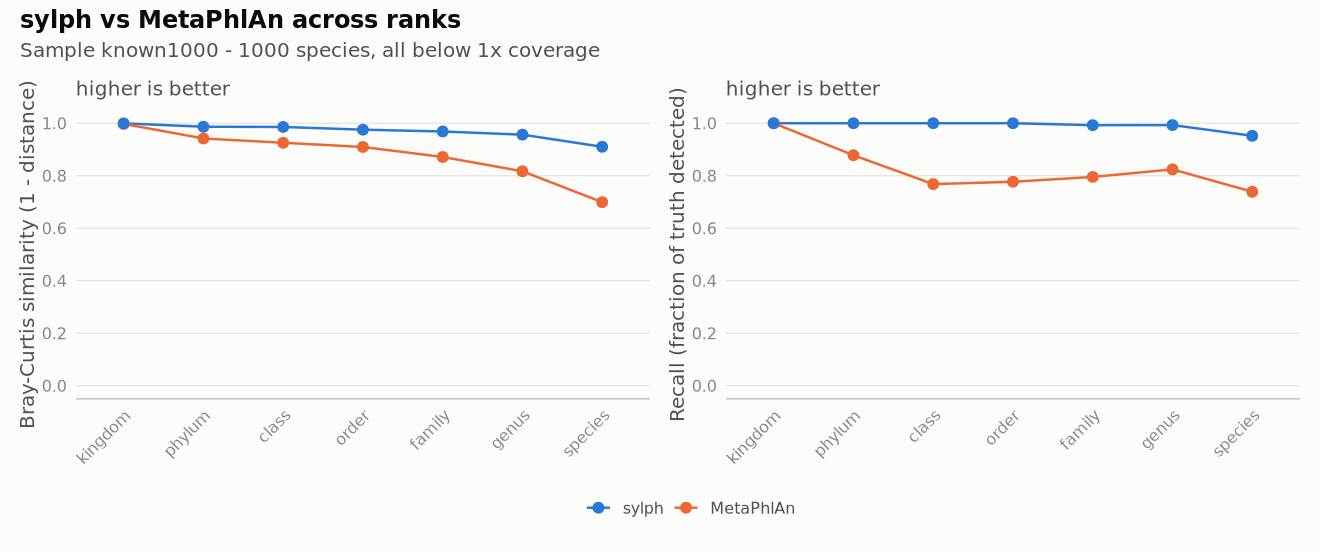

In [33]:
options(repr.plot.width = 11, repr.plot.height = 4.6)
two <- c('sylph', 'metaphlan')
rank_sweep(two, 'sylph vs MetaPhlAn across ranks')

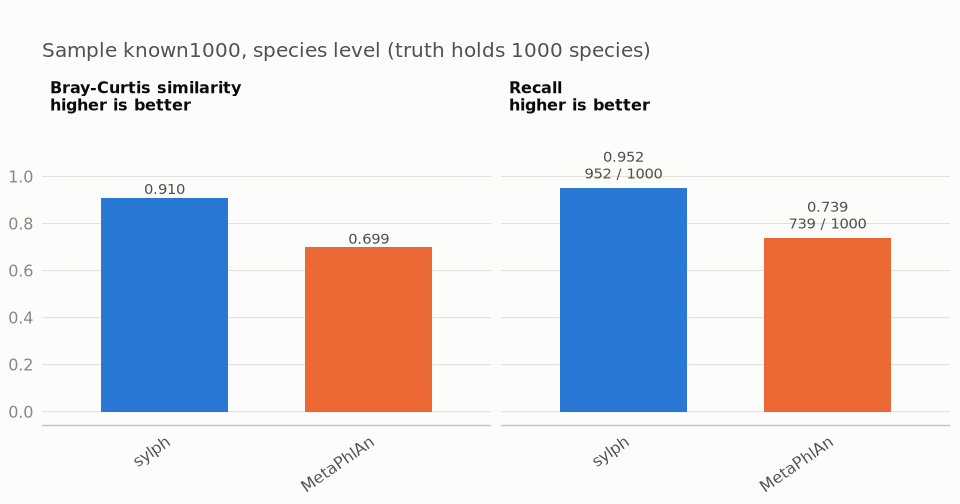

In [34]:
options(repr.plot.width = 8, repr.plot.height = 4.2)
species_bars(two, '')#sylph vs MetaPhlAn at the species level')

In [35]:
# The species-level numbers behind the bars. True positives is recall x 1000, and
# F1 / purity are kept in the tables even though the plots show recall.
dcast(
  metrics[tool %in% two & rank == 'species' &
          metric %in% c('Bray-Curtis distance', 'Recall', 'Purity', 'F1 score',
                        'True positives', 'False positives', 'False negatives')],
  tool_label ~ metric, value.var = 'value'
)

tool_label,Bray-Curtis distance,F1 score,False negatives,False positives,Purity,Recall,True positives
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sylph,0.08975013,0.9669883,48,17,0.9824561,0.952,952
MetaPhlAn,0.30077305,0.8275476,261,47,0.9402036,0.739,739


## 2 · adding vanilla SingleM

SingleM's marker-gene sensitivity floor is around 1.5× coverage, and *no* member
of this community reaches it. Its curve is the control showing what the floor
costs: the question is not whether these species are in its database (they all
are, as a different strain) but whether they can be seen at this depth.

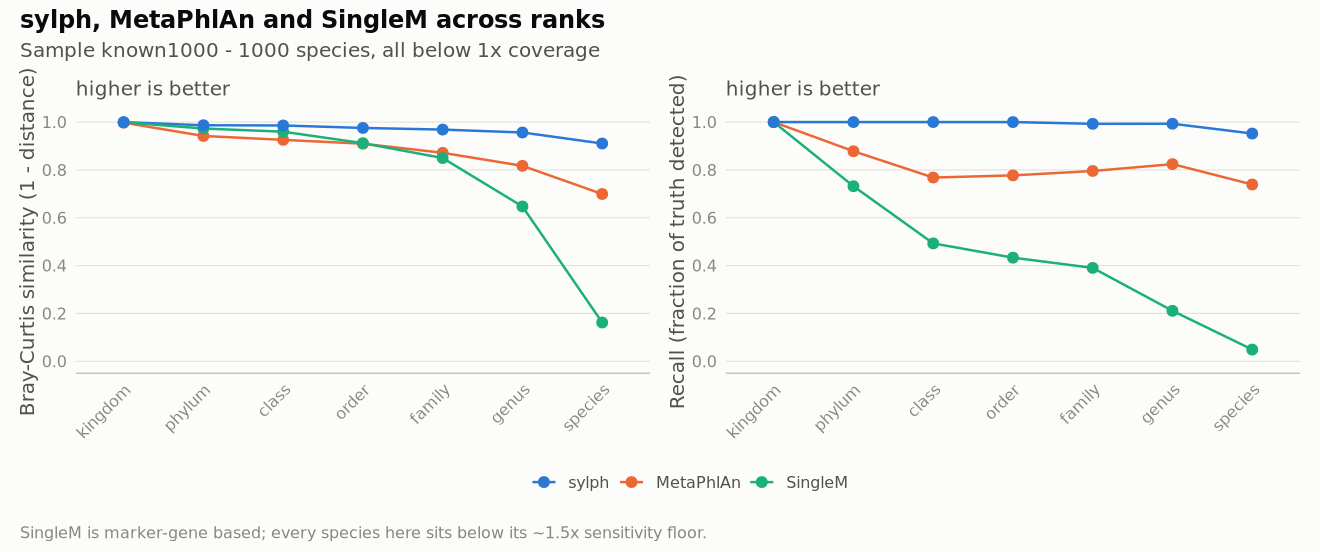

In [36]:
options(repr.plot.width = 11, repr.plot.height = 4.6)
three <- c('sylph', 'metaphlan', 'singlem')
rank_sweep(three, 'sylph, MetaPhlAn and SingleM across ranks',
           caption = 'SingleM is marker-gene based; every species here sits below its ~1.5x sensitivity floor.')

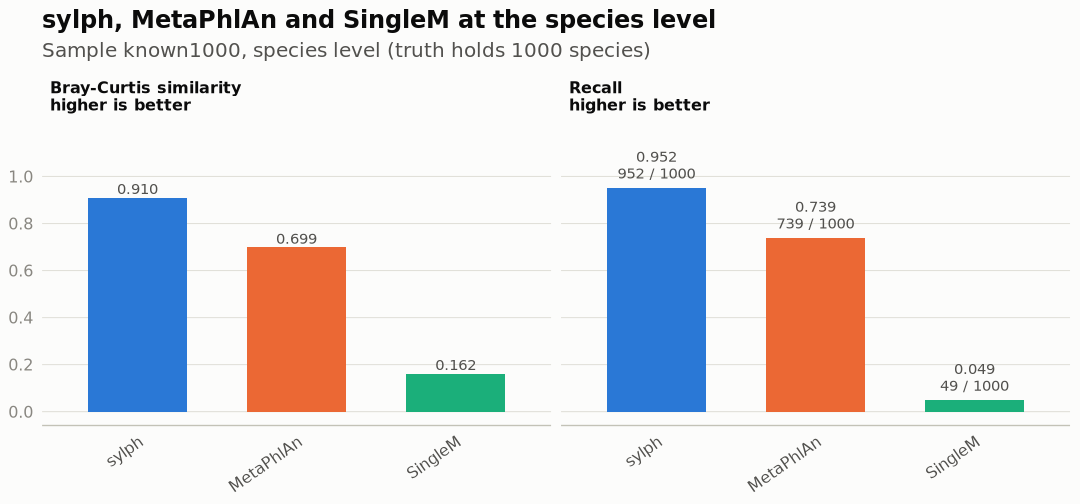

In [37]:
options(repr.plot.width = 9, repr.plot.height = 4.2)
species_bars(three, 'sylph, MetaPhlAn and SingleM at the species level')

In [38]:
# Recall and purity separately: vanilla SingleM's problem here is recall, not
# precision -- what little it does report is nearly all correct.
dcast(
  metrics[tool %in% three & rank == 'species' &
          metric %in% c('Recall', 'Purity', 'F1 score', 'Bray-Curtis distance',
                        'True positives', 'False positives')],
  tool_label ~ metric, value.var = 'value'
)

tool_label,Bray-Curtis distance,F1 score,False positives,Purity,Recall,True positives
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sylph,0.08975013,0.96698832,17,0.9824561,0.952,952
MetaPhlAn,0.30077305,0.82754759,47,0.9402036,0.739,739
SingleM,0.83797981,0.09315589,3,0.9423077,0.049,49


## 3 · all four methods

`singlem-regime3` is the joint method: weebill (a sylph fork) prefilters candidate
genomes, then SingleM `condense --joint` places the marker evidence against that
shortlist. It is the answer to "how much of the floor is inherent to marker genes,
and how much is recoverable given a whole-genome prior?".

It is now run with weebill `-u` and `--alpha 1` (so condense reads `True_cov`
already on SingleM's scale), plus `--joint-pin-sylph-species` and
`--joint-novel-budget` — the alpha-calibration caveat in earlier versions of this
benchmark's README no longer applies.

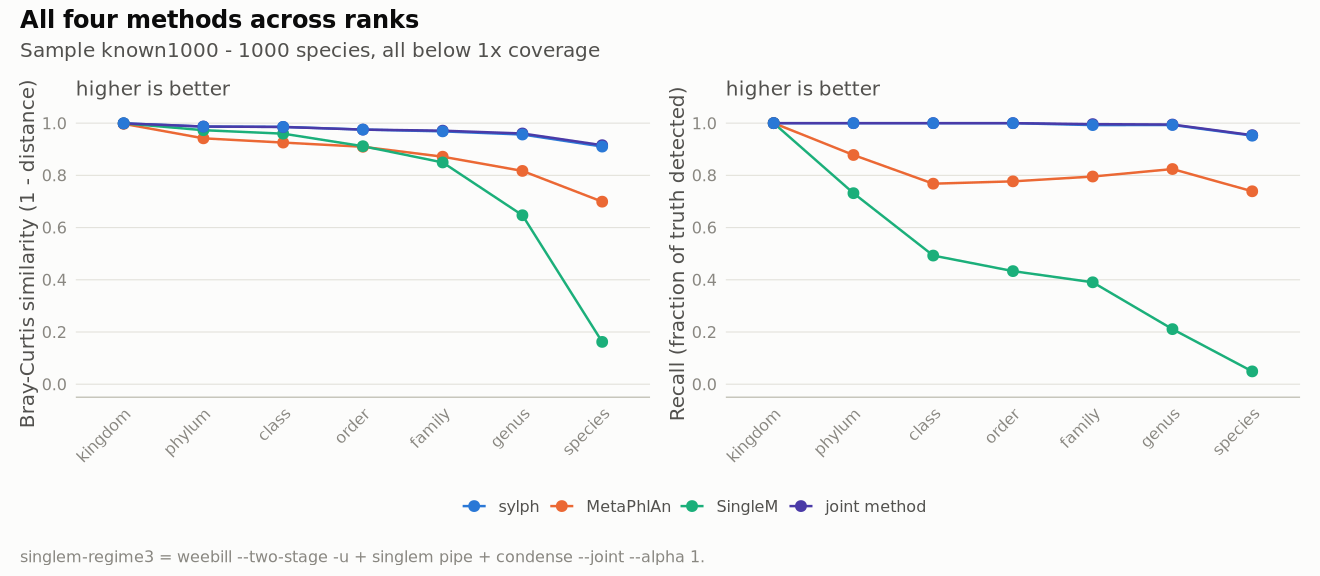

In [39]:
options(repr.plot.width = 11, repr.plot.height = 4.8)
all_four <- tool_meta$tool
rank_sweep(all_four, 'All four methods across ranks',
           caption = 'singlem-regime3 = weebill --two-stage -u + singlem pipe + condense --joint --alpha 1.')

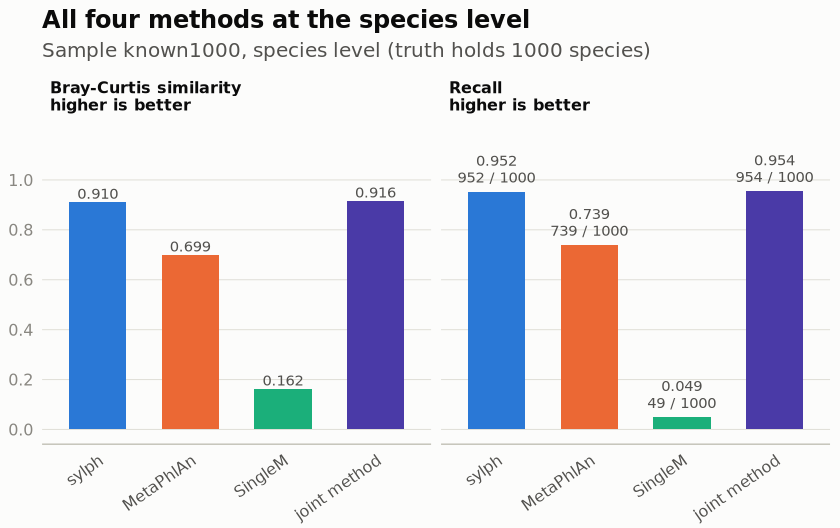

In [44]:
options(repr.plot.width = 7, repr.plot.height = 4.4)
species_bars(all_four, 'All four methods at the species level')

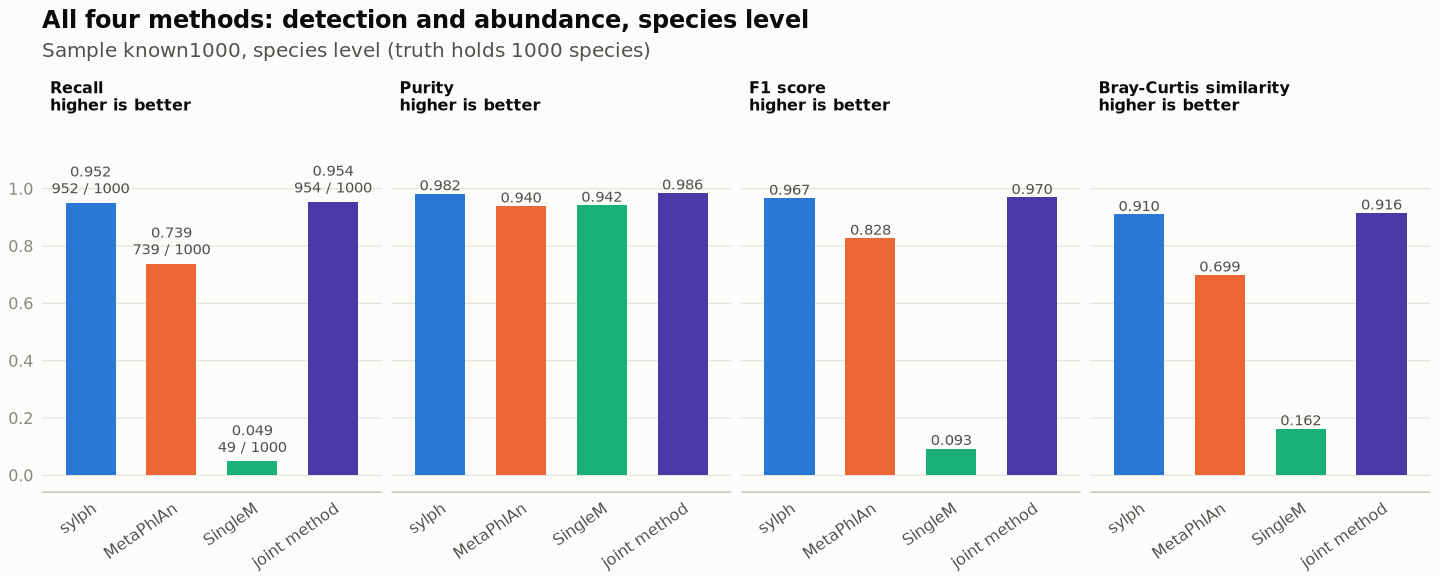

In [41]:
# Recall beside purity, so nothing the recall-only plots leave out is hidden:
# purity is high for everyone, which is why the whole spread sits in recall and
# why recall rather than F1 is the informative axis here.
options(repr.plot.width = 12, repr.plot.height = 4.8)
species_bars(all_four, 'All four methods: detection and abundance, species level',
             metric_names = c('Recall', 'Purity', 'F1 score', 'Bray-Curtis distance'))

## Summary table

Species-level values for every tool, written out alongside the full rank sweep
for downstream use (`accuracy_results.csv`).

In [42]:
species_summary <- dcast(
  metrics[rank == 'species' &
          metric %in% c('Recall', 'Purity', 'F1 score', 'Bray-Curtis distance',
                        'True positives', 'False positives', 'False negatives')],
  tool_label ~ metric, value.var = 'value'
)[order(-Recall)]
species_summary[, `species found` := paste0(round(Recall * n_species), ' / ', n_species)]
species_summary[]

tool_label,Bray-Curtis distance,F1 score,False negatives,False positives,Purity,Recall,True positives,species found
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
joint method,0.08446389,0.96951220,46,14,0.9855372,0.954,954,954 / 1000
sylph,0.08975013,0.96698832,48,17,0.9824561,0.952,952,952 / 1000
MetaPhlAn,0.30077305,0.82754759,261,47,0.9402036,0.739,739,739 / 1000
SingleM,0.83797981,0.09315589,951,3,0.9423077,0.049,49,49 / 1000


In [43]:
fwrite(metrics[, .(tool, rank, metric, value)], 'accuracy_results.csv', sep = '\t')
fwrite(species_summary, 'species_level_summary.csv')